In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
sys.path.append(str(project_root))
sys.path.append(str(project_root / "src"))

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2
from dotenv import load_dotenv
from sqlalchemy import create_engine, text

from src.config import SupabaseConfig
from src.risk_engine.backtesting import rolling_backtest, kupiec_pof_test

In [3]:
load_dotenv()
cfg = SupabaseConfig.from_env()
engine = create_engine(cfg.sqlalchemy_url())

with engine.connect() as conn:
    print(conn.execute(text("SELECT 1")).scalar())

1


In [4]:
# Load returns + weights from Supabase (same pattern as notebook 02)
query = """
SELECT
    dd.date_id AS date,
    da.ticker,
    fr.simple_return
FROM fact_returns fr
JOIN dim_date dd ON fr.date_id = dd.date_id
JOIN dim_asset da ON fr.asset_id = da.asset_id
ORDER BY dd.date_id, da.ticker;
"""

returns_long = pd.read_sql(query, engine)
returns_long['date'] = pd.to_datetime(returns_long['date'])
returns_df = returns_long.pivot(index='date', columns='ticker', values='simple_return')

weights_query = """
SELECT
    da.ticker,
    dpw.weight
FROM dim_asset da
JOIN dim_portfolio_weight dpw ON da.asset_id = dpw.asset_id
JOIN dim_portfolio dp ON dpw.portfolio_id = dp.portfolio_id;
"""
weights = pd.read_sql(weights_query, engine).set_index('ticker')['weight']

print(returns_df.shape, "| weights sum:", weights.sum())
returns_df.head()

(5437, 14) | weights sum: 1.00002


ticker,AAPL,CAT,DIS,F,GS,JNJ,JPM,MDT,MSFT,NEE,NEM,PG,WMT,XOM
date,,,,,,,,,,,,,,
2005-01-04,0.010270,-0.011045,-0.010772,-0.003399,-0.006479,-0.003180,-0.010307,-0.004653,0.003739,-0.012179,-0.018650,-0.012502,-0.002436,-0.006788
2005-01-05,0.008758,-0.019145,-0.005445,-0.015689,-0.004507,-0.000638,0.002083,-0.007432,-0.002235,-0.012877,0.002406,0.010459,0.001315,-0.005226
2005-01-06,0.000776,0.014748,0.001460,0.001386,0.013777,0.002872,0.005716,0.020513,-0.001121,0.016237,-0.001680,0.004903,0.014262,0.012729
2005-01-07,0.072812,-0.002138,-0.009840,0.013841,-0.004276,-0.003660,-0.008009,0.009045,-0.002991,-0.001912,-0.002404,0.010480,-0.001110,-0.006584
2005-01-10,-0.004187,-0.009209,0.004049,-0.006826,0.001908,0.007826,-0.003385,0.023108,0.004874,0.003420,0.003856,0.007869,-0.005001,0.003816


In [5]:
# 1. Rolling backtest -- VaR predicted for day t uses only data strictly before day t
confidence = 0.95
window = 250

backtest_results = rolling_backtest(returns_df, weights, method="historical", confidence=confidence, window=window)
print(f"{len(backtest_results)} backtest days, {backtest_results['breach'].sum()} breaches "
      f"({backtest_results['breach'].mean():.2%} observed vs {1-confidence:.2%} expected)")
backtest_results.head()

5187 backtest days, 293 breaches (5.65% observed vs 5.00% expected)


,date_id,method,confidence,predicted_var_pct,realized_return_pct,breach
0,2005-12-30,historical,0.95,0.011592,-0.005127,False
1,2006-01-03,historical,0.95,0.011592,0.019805,False
2,2006-01-04,historical,0.95,0.011592,0.004799,False
3,2006-01-05,historical,0.95,0.011592,-0.000222,False
4,2006-01-06,historical,0.95,0.011592,0.011850,False


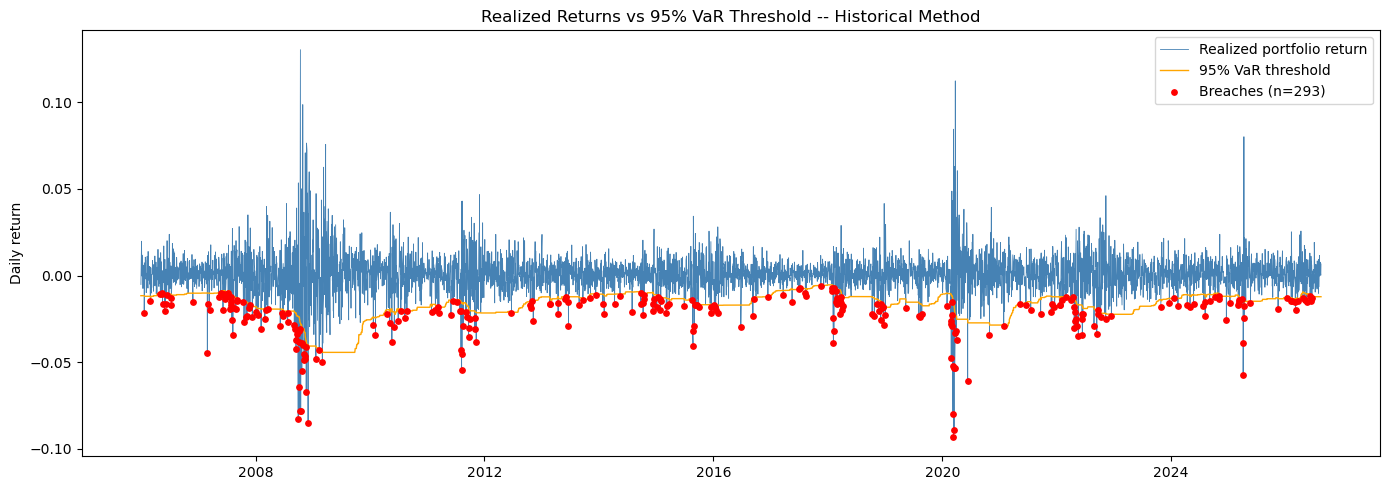

Breaches by year:
date_id
2006    12
2007    28
2008    33
2009     3
2010    10
2011    21
2012     5
2013    12
2014    14
2015    19
2016     8
2017     7
2018    27
2019     5
2020    18
2021     8
2022    24
2023     2
2024    14
2025    11
2026    12
Name: count, dtype: int64


In [6]:
# 2. Realized returns vs. VaR threshold, breaches marked
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(backtest_results['date_id'], backtest_results['realized_return_pct'],
        label='Realized portfolio return', linewidth=0.6, color='steelblue')
ax.plot(backtest_results['date_id'], -backtest_results['predicted_var_pct'],
        label=f'{int(confidence*100)}% VaR threshold', color='orange', linewidth=1)

breaches = backtest_results[backtest_results['breach']]
ax.scatter(breaches['date_id'], breaches['realized_return_pct'],
           color='red', s=15, zorder=5, label=f'Breaches (n={len(breaches)})')

ax.set_title(f'Realized Returns vs {int(confidence*100)}% VaR Threshold -- Historical Method')
ax.set_ylabel('Daily return')
ax.legend()
plt.tight_layout()
plt.show()

breaches_by_year = breaches['date_id'].dt.year.value_counts().sort_index()
print("Breaches by year:")
print(breaches_by_year)

In [7]:
# 3. Kupiec POF test by hand -- toy example (n=250, x=15 breaches, 95% confidence)
n_toy, x_toy, conf_toy = 250, 15, 0.95

p_expected_toy = 1 - conf_toy
p_observed_toy = x_toy / n_toy

ll_expected = (n_toy - x_toy) * np.log(1 - p_expected_toy) + x_toy * np.log(p_expected_toy)
ll_observed = (n_toy - x_toy) * np.log(1 - p_observed_toy) + x_toy * np.log(p_observed_toy)

LR_toy = -2 * (ll_expected - ll_observed)
p_value_toy = 1 - chi2.cdf(LR_toy, df=1)

print(f"By hand:      LR = {LR_toy:.4f}, p-value = {p_value_toy:.4f}")

toy_breach_series = pd.Series([True] * x_toy + [False] * (n_toy - x_toy))
toy_result = kupiec_pof_test(toy_breach_series, confidence=conf_toy)
print(f"From function: LR = {toy_result['lr_statistic']:.4f}, p-value = {toy_result['p_value']:.4f}")

assert np.isclose(LR_toy, toy_result['lr_statistic']), "Mismatch between hand calc and function!"
print("\nMatch confirmed.")

By hand:      LR = 0.4961, p-value = 0.4812
From function: LR = 0.4961, p-value = 0.4812

Match confirmed.


In [8]:
# 4. Kupiec test on the actual backtest, and interpretation
actual_result = kupiec_pof_test(backtest_results['breach'], confidence=confidence)

for k, v in actual_result.items():
    if k != 'verdict':
        print(f"{k}: {v}")

print()
print(actual_result['verdict'])

n_observations: 5187
n_breaches: 293
expected_breach_rate: 0.050000000000000044
observed_breach_rate: 0.056487372276845964
lr_statistic: 4.418861828174158
p_value: 0.035543737422938926
reject_h0_at_5pct: True

Model REJECTED at 5% significance (p=0.0355). Observed breach rate (5.65%) is significantly HIGHER than expected (5.00%) -- the model is underestimating risk (too many losses exceed predicted VaR).


## 5. Push backtest results to Supabase (`fact_var_backtest`)

In [9]:
from src.universe import PORTFOLIO_NAME

portfolio_id = pd.read_sql(
    "SELECT portfolio_id FROM dim_portfolio WHERE portfolio_name = %(name)s",
    engine, params={"name": PORTFOLIO_NAME}
)["portfolio_id"].iloc[0]

backtest_to_store = backtest_results.copy()
backtest_to_store["portfolio_id"] = int(portfolio_id)
backtest_to_store["date_id"] = pd.to_datetime(backtest_to_store["date_id"]).dt.date

# Bulk delete any prior rows for this (portfolio, method, confidence) --
# single statement, not per-row -- then bulk append. Same fast pattern as
# notebook 01's fact_price/fact_returns inserts (method="multi", chunked),
# rather than a per-row ON CONFLICT upsert, which does one network
# round-trip per row and is far too slow at 5000+ rows.
with engine.begin() as conn:
    conn.execute(
        text("""
            DELETE FROM fact_var_backtest
            WHERE portfolio_id = :portfolio_id AND method = :method AND confidence = :confidence
        """),
        {"portfolio_id": int(portfolio_id), "method": "historical", "confidence": confidence},
    )

cols = ["date_id", "portfolio_id", "method", "confidence", "predicted_var_pct", "realized_return_pct", "breach"]
backtest_to_store[cols].to_sql(
    "fact_var_backtest", engine, if_exists="append", index=False,
    method="multi", chunksize=1000
)

print(f"Inserted {len(backtest_to_store)} rows into fact_var_backtest")

Inserted 5187 rows into fact_var_backtest
